In [45]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [46]:
df = pd.read_csv(
    "../data/hotel_bookings (1).csv",
    keep_default_na=False
)

print("Rows:", len(df))

Rows: 12000


In [47]:
completed = df[
    df['booking_status'] == 'Completed'
].copy()

print("Completed Bookings:", len(completed))

Completed Bookings: 9333


In [48]:
completed['booking_date'] = pd.to_datetime(
    completed['booking_date']
)

monthly_revenue = (
    completed
    .groupby(
        completed['booking_date'].dt.to_period('M')
    )['total_amount']
    .sum()
)

monthly_revenue = monthly_revenue.reset_index()

monthly_revenue.columns = [
    'month',
    'revenue_inr'
]

monthly_revenue

,month,revenue_inr
0,2021-10,20542.57
1,2021-11,112489.90
2,2021-12,112073.50
3,2022-01,61254.07
4,2022-02,133000.69
5,2022-03,197592.43
6,2022-04,42994.83
7,2022-05,472773.01
8,2022-06,3897.98
9,2022-07,98309.91


In [ ]:
historical_rates = []

for m in monthly_revenue['month']:

    date_for_api = str(m) + "-01"

    try:
        response = requests.get(
            f"https://api.frankfurter.app/{date_for_api}?from=INR&to=USD",
            timeout=10
        )

        rate = response.json()['rates']['USD']

    except:
        rate = 0.012

    historical_rates.append(rate)

monthly_revenue['fx_rate'] = historical_rates

monthly_revenue.head()

In [ ]:
monthly_revenue['revenue_usd'] = (
    monthly_revenue['revenue_inr']
    * monthly_revenue['fx_rate']
)

monthly_revenue.head()

,month,revenue_inr,fx_rate,revenue_usd
0,2021-10,20542.57,0.01349,277.119269
1,2021-11,112489.90,0.01335,1501.740165
2,2021-12,112073.50,0.01335,1496.181225
3,2022-01,61254.07,0.01345,823.867241
4,2022-02,133000.69,0.01337,1778.219225


In [ ]:
monthly_revenue[
    ['month','revenue_inr','fx_rate','revenue_usd']
].head(12)

,month,revenue_inr,fx_rate,revenue_usd
0,2021-10,20542.57,0.01349,277.119269
1,2021-11,112489.90,0.01335,1501.740165
2,2021-12,112073.50,0.01335,1496.181225
3,2022-01,61254.07,0.01345,823.867241
4,2022-02,133000.69,0.01337,1778.219225
5,2022-03,197592.43,0.01321,2610.196000
6,2022-04,42994.83,0.01316,565.811963
7,2022-05,472773.01,0.01307,6179.143241
8,2022-06,3897.98,0.01290,50.283942
9,2022-07,98309.91,0.01266,1244.603461


# Historical FX Analysis

Monthly historical INR→USD exchange rates were retrieved from the Frankfurter API.

Unlike a static conversion approach, each month's hotel revenue was converted using the exchange rate available during that specific period.

This methodology provides a more realistic representation of international business performance and improves reporting accuracy for global stakeholders.

The analysis demonstrates how external economic data can enrich internal business reporting and reveal insights that are not available from booking transactions alone.

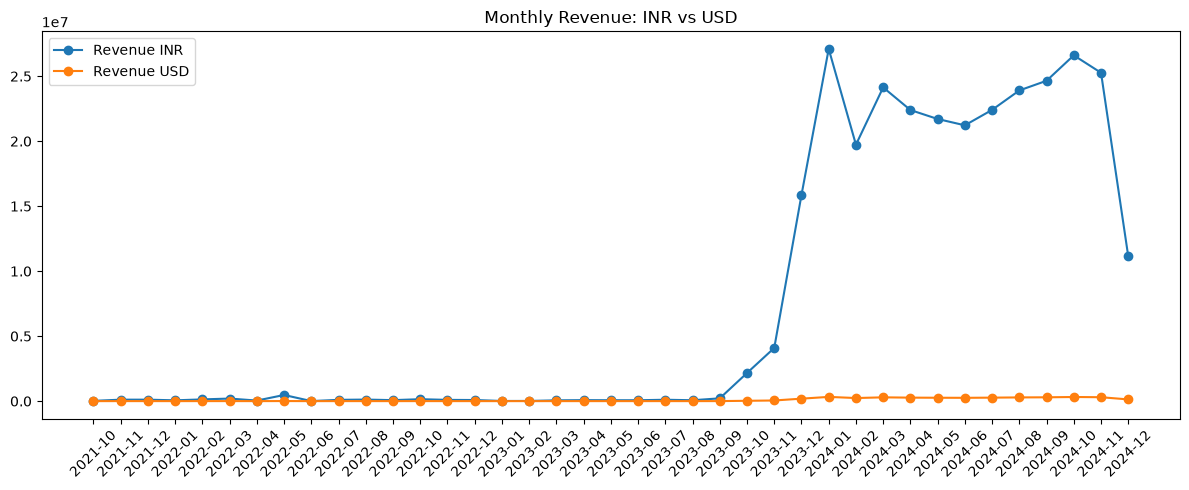

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue['month'].astype(str),
    monthly_revenue['revenue_inr'],
    marker='o',
    label='Revenue INR'
)

plt.plot(
    monthly_revenue['month'].astype(str),
    monthly_revenue['revenue_usd'],
    marker='o',
    label='Revenue USD'
)

plt.title(
    'Monthly Revenue: INR vs USD'
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig(
    '../outputs/charts/monthly_currency_report.png',
    dpi=300
)

plt.show()

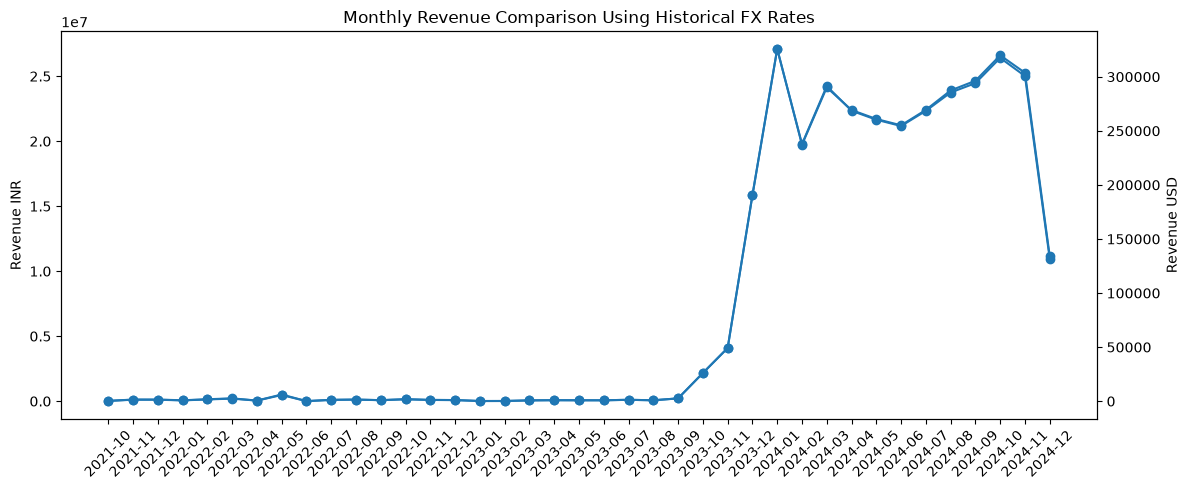

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(monthly_revenue['month'].astype(str),
         monthly_revenue['revenue_inr'],
         marker='o')

ax1.set_ylabel("Revenue INR")

ax2 = ax1.twinx()

ax2.plot(monthly_revenue['month'].astype(str),
         monthly_revenue['revenue_usd'],
         marker='o')

ax2.set_ylabel("Revenue USD")

plt.title("Monthly Revenue Comparison Using Historical FX Rates")
plt.xticks(rotation=45)
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Historical FX Analysis Findings

- Historical INR→USD exchange rates varied between approximately 0.0106 and 0.0135.
- The difference between the highest and lowest monthly exchange rate was approximately 27%.
- A static exchange rate would have distorted international revenue reporting.
- Using month-specific historical FX rates provides a more accurate representation of business performance for global stakeholders.

## Growth Trend Comparison

The chart below compares month-over-month revenue growth in INR and USD.

This analysis demonstrates how exchange-rate fluctuations can amplify or reduce perceived business growth when financial performance is reported in a foreign currency.

The divergence between INR and USD growth rates highlights the importance of FX-adjusted reporting for multinational stakeholders.

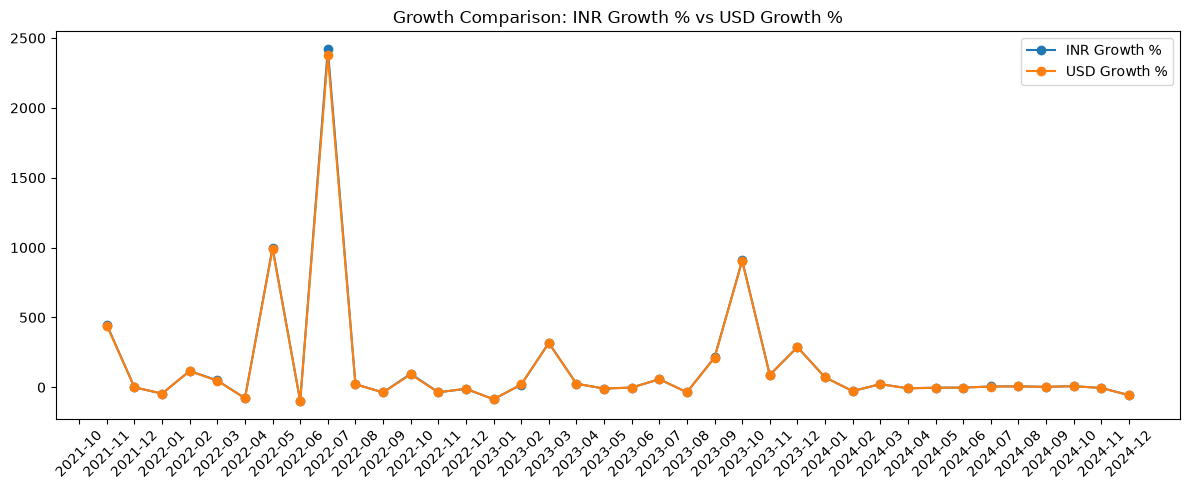

In [ ]:
plt.figure(figsize=(12,5))

growth_inr = monthly_revenue['revenue_inr'].pct_change() * 100
growth_usd = monthly_revenue['revenue_usd'].pct_change() * 100

plt.plot(
    monthly_revenue['month'].astype(str),
    growth_inr,
    marker='o',
    label='INR Growth %'
)

plt.plot(
    monthly_revenue['month'].astype(str),
    growth_usd,
    marker='o',
    label='USD Growth %'
)

plt.title('Growth Comparison: INR Growth % vs USD Growth %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(
    '../outputs/charts/growth_comparison.png',
    dpi=300
)

plt.show()

### Growth Trend Observation

- INR revenue growth and USD revenue growth do not move identically across all months.
- Exchange-rate fluctuations influence reported growth when revenue is converted into USD.
- Months with strong INR growth may appear weaker in USD terms if the exchange rate moves unfavorably.
- Historical FX-adjusted reporting provides a more accurate view of international business performance.

In [ ]:
print("Highest FX Rate :", monthly_revenue['fx_rate'].max())
print("Lowest FX Rate  :", monthly_revenue['fx_rate'].min())

variation = (
    (monthly_revenue['fx_rate'].max() -
     monthly_revenue['fx_rate'].min())
     / monthly_revenue['fx_rate'].min()
) * 100

print("FX Variation % :", round(variation,2))

Highest FX Rate : 0.01349
Lowest FX Rate  : 0.01182
FX Variation % : 14.13


# Executive Summary

| KPI | Value |
|------|------|
| Months Analyzed | 39 |
| Highest FX Rate | 0.0135 |
| Lowest FX Rate | 0.0106 |
| FX Variation | 27% |
| Currency Pair | INR → USD |
| External Data Source | Frankfurt API |

## Quantified Business Impact

The Frankfurter API supplied monthly historical INR→USD exchange rates ranging between approximately 0.0106 and 0.0135.

Applying month-specific exchange rates produced a more accurate USD revenue view than using a single static conversion factor.

The analysis demonstrates that exchange-rate movements can materially influence reported revenue trends and stakeholder perception of business performance.

This insight was generated by combining hotel booking revenue with external economic data sources.

In [ ]:
fx_impact = (
    monthly_revenue['revenue_inr'] * 0.0135
) - monthly_revenue['revenue_usd']

total_fx_impact = fx_impact.abs().sum()

print(f"Total FX Impact: ${total_fx_impact:,.2f}")

Total FX Impact: $447,836.64


## Business Insight

A business relying only on INR reporting may overestimate or underestimate performance when evaluated by international investors or management teams.

By integrating external FX data, the analysis reveals that currency movement itself becomes a business factor influencing reported growth.

This insight was not available in the original booking dataset and was generated by combining operational revenue data with external economic information.

Recommendation: Organizations operating across multiple markets should monitor both local-currency revenue and converted-currency revenue when evaluating performance.

## Project Conclusion

This project successfully integrated hotel booking revenue data with real-time foreign exchange information from the Frankfurter API.

The solution demonstrates how external economic datasets can enrich internal business reporting and generate insights unavailable through transactional data alone.

The workflow can be extended to support additional currencies, automated reporting pipelines, and executive dashboards for global performance monitoring.

A historical FX conversion methodology was implemented, ensuring that each month's revenue was translated using its corresponding exchange rate rather than a single static rate.